# **Load and Process Images**

In [44]:
import os
import cv2
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

DATASET_PATH = "/content/drive/MyDrive/brain_tumor_dataset"
IMG_SIZE = 128

features = []
labels = []

def preprocess_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Crop the brain area
    _, thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        c = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(c)
        gray = gray[y:y+h, x:x+w]
        gray = cv2.resize(gray, (IMG_SIZE, IMG_SIZE))  # Resize after crop

    # Gaussian Blur
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Thresholding
    _, thresholded = cv2.threshold(blurred, 60, 255, cv2.THRESH_BINARY)

    return thresholded

for category in ["yes", "no"]:
    folder = os.path.join(DATASET_PATH, category)
    label = 1 if category == "yes" else 0

    for file in os.listdir(folder):
        if file.endswith(".jpg") or file.endswith(".png"):
            path = os.path.join(folder, file)
            try:
                processed = preprocess_image(path)
                features.append(processed)
                labels.append(label)
            except Exception as e:
                print(f"Error processing {file}: {e}")

features = np.array(features)
labels = np.array(labels)

print("Images loaded and preprocessed!")
print("Shape of dataset:", features.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Images loaded and preprocessed!
Shape of dataset: (173, 128, 128)


# **Feature Extraction**

In [45]:
from scipy.stats import skew, entropy
from skimage.feature import graycomatrix, graycoprops

# Define GLCM distances and angles
distances = [1, 2, 3]
angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]
glcm_props = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation']

def extract_features(image):
    feature_vector = []

    flat = image.flatten()

    # Statistical Features
    mean_val = np.mean(flat)
    std_val = np.std(flat)
    var_val = np.var(flat)
    skewness_val = skew(flat)
    entropy_val = entropy(np.histogram(flat, bins=256)[0] + 1)  # Avoid log(0)

    feature_vector.extend([mean_val, std_val, var_val, skewness_val, entropy_val])

    # GLCM Features
    glcm = graycomatrix(image, distances=distances, angles=angles, levels=256,
                        symmetric=True, normed=True)

    for prop in glcm_props:
        prop_vals = graycoprops(glcm, prop)
        for i, d in enumerate(distances):
            for j, a in enumerate(angles):
                feature_vector.append(prop_vals[i, j])  # specific (d,a) value

    return feature_vector


extracted_features = [extract_features(img) for img in features]

X = np.array(extracted_features)
y = labels

feature_names = ["Mean", "StdDev", "Variance", "Skewness", "Entropy"]
for prop in glcm_props:
    for d in distances:
        for a in angles:
            angle_deg = int(np.rad2deg(a))
            feature_names.append(f"{prop}_d{d}_a{angle_deg}")

In [46]:
import pandas as pd

df_features = pd.DataFrame(X, columns=feature_names)
df_features['Label'] = y

print(df_features.head())

df_features.to_csv("extracted_features.csv", index=False)

         Mean      StdDev      Variance  Skewness   Entropy  contrast_d1_a0  \
0  121.959229  127.379550  16225.549851  0.086996  0.845148     3248.049951   
1  194.331665  108.580747  11789.778548 -1.231004  0.703837     2216.034080   
2  194.191589  108.666839  11808.481909 -1.227451  0.704466     2364.036356   
3  163.530579  122.303096  14958.047405 -0.589201  0.806227     2596.039924   
4  185.382385  113.604047  12905.879477 -1.019020  0.740819     2816.043307   

   contrast_d1_a45  contrast_d1_a90  contrast_d1_a135  contrast_d2_a0  ...  \
0      4249.262199      2672.041093       4297.640895     6467.020089  ...   
1      3580.023560      2136.032849       3644.528489     4394.670759  ...   
2      3172.836196      1992.030635       3035.763222     4547.879464  ...   
3      3858.201066      2600.039985       3664.686279     5128.459821  ...   
4      3584.055118      2380.036602       3535.676421     5386.495536  ...   

   correlation_d1_a135  correlation_d2_a0  correlation_d

# **Modeling**

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

model_results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    print(f"{name} Confusion Matrix:\n{cm}")

    model_results[name] = {
        "model": model,
        "y_pred": y_pred,
        "confusion_matrix": cm
    }



Training SVM...

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.47      0.47        17
           1       0.50      0.50      0.50        18

    accuracy                           0.49        35
   macro avg       0.49      0.49      0.49        35
weighted avg       0.49      0.49      0.49        35

SVM Confusion Matrix:
[[8 9]
 [9 9]]

Training Random Forest...

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.76      0.63        17
           1       0.64      0.39      0.48        18

    accuracy                           0.57        35
   macro avg       0.59      0.58      0.56        35
weighted avg       0.59      0.57      0.56        35

Random Forest Confusion Matrix:
[[13  4]
 [11  7]]

Training KNN...

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.59      0.53     

# **Evaluation**

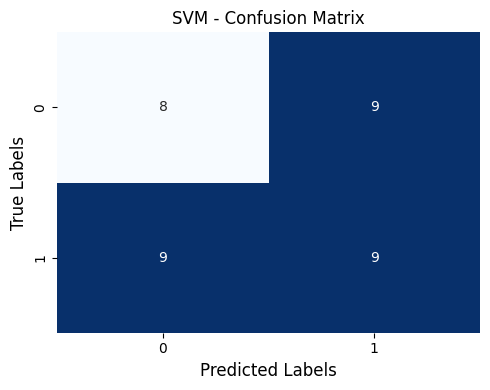

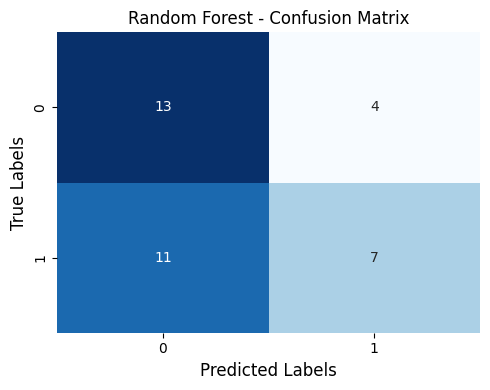

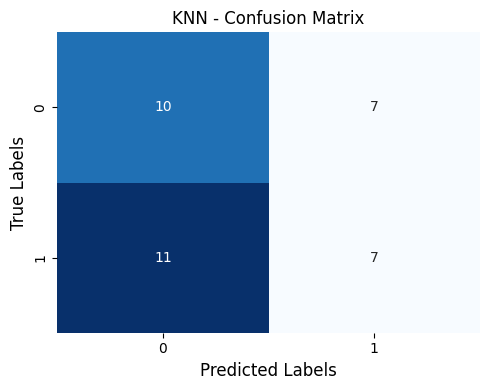

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"{title} - Confusion Matrix")
    plt.xlabel('Predicted Labels', fontsize=12)
    plt.ylabel('True Labels', fontsize=12)
    plt.tight_layout()
    plt.show()


for name, result in model_results.items():
    plot_confusion_matrix(result['confusion_matrix'], name)

In [50]:
metrics = {
    "Model": [],
    "Accuracy": [],
    "F1 Score": [],
    "Precision": [],
    "Recall": []
}

for name, result in model_results.items():
    y_pred = result['y_pred']
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)

    metrics["Model"].append(name)
    metrics["Accuracy"].append(acc)
    metrics["F1 Score"].append(f1)
    metrics["Precision"].append(prec)
    metrics["Recall"].append(rec)

df_metrics = pd.DataFrame(metrics)

print("\n=== Model Evaluation Metrics ===\n")
print(df_metrics.to_string(index=False))


=== Model Evaluation Metrics ===

        Model  Accuracy  F1 Score  Precision   Recall
          SVM  0.485714  0.500000   0.500000 0.500000
Random Forest  0.571429  0.482759   0.636364 0.388889
          KNN  0.485714  0.437500   0.500000 0.388889


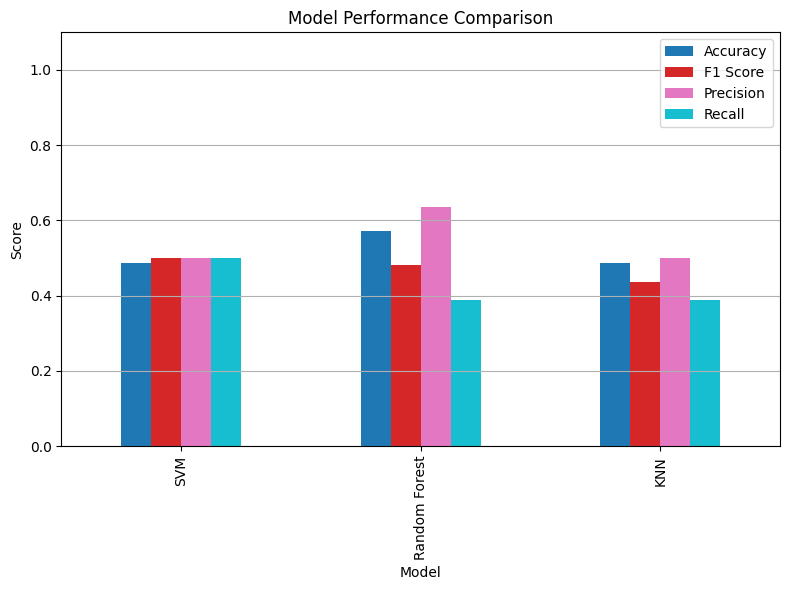

In [51]:
df_metrics.set_index("Model").plot(kind="bar", figsize=(8, 6), colormap="tab10")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

<ipython-input-52-47f3cd01eac3>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices][:20], y=np.array(feature_names)[indices][:20], palette="crest")


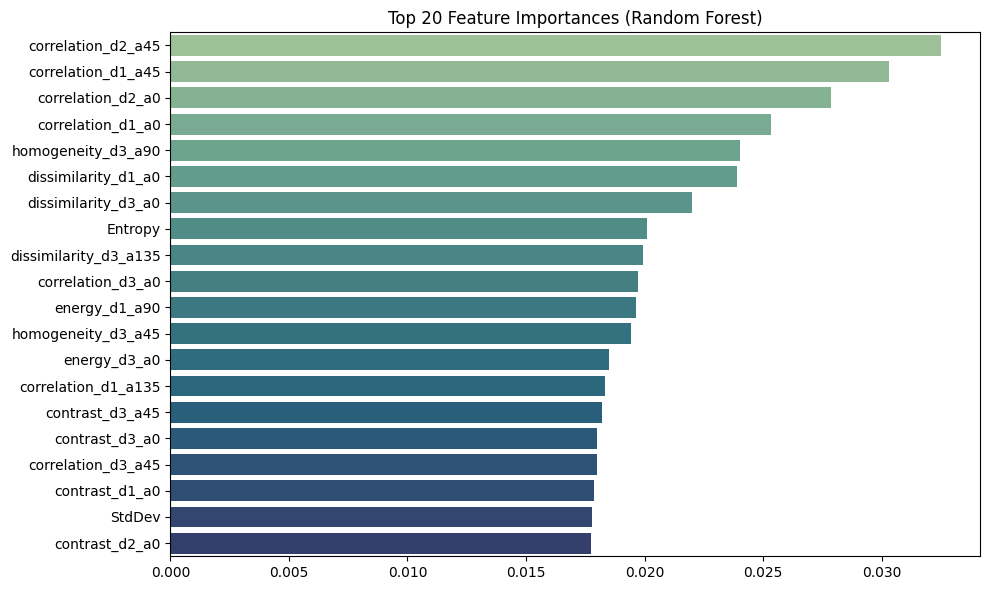

In [52]:
# Feature importances (Random Forest only)
rf_model = model_results["Random Forest"]["model"]
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Top features plot
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices][:20], y=np.array(feature_names)[indices][:20], palette="crest")
plt.title("Top 20 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()

# **Some Classified Images**


SVM - Classified Image Samples:


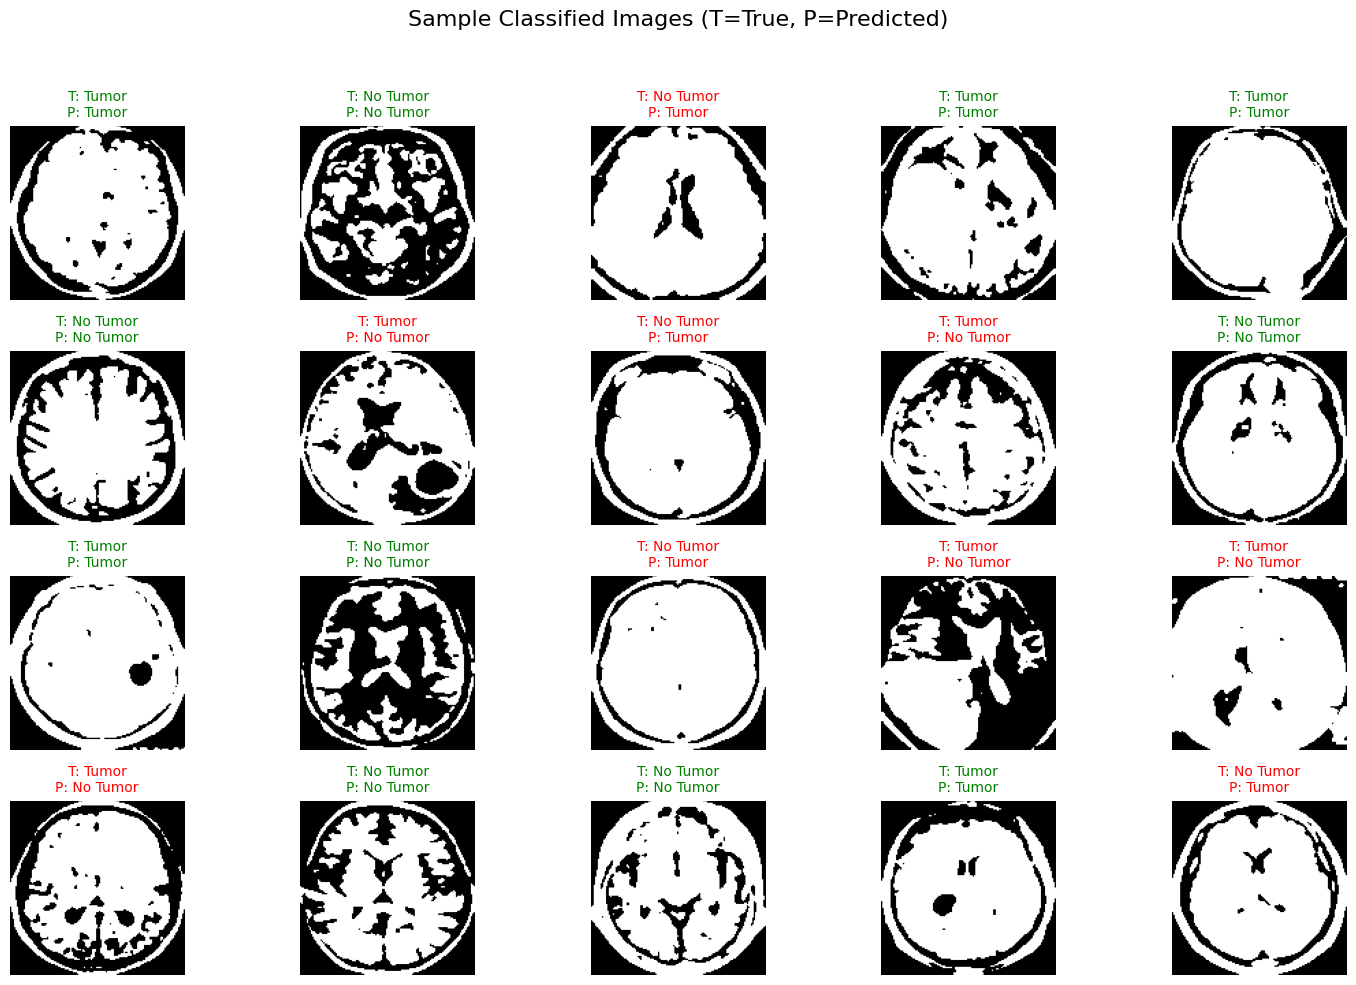


Random Forest - Classified Image Samples:


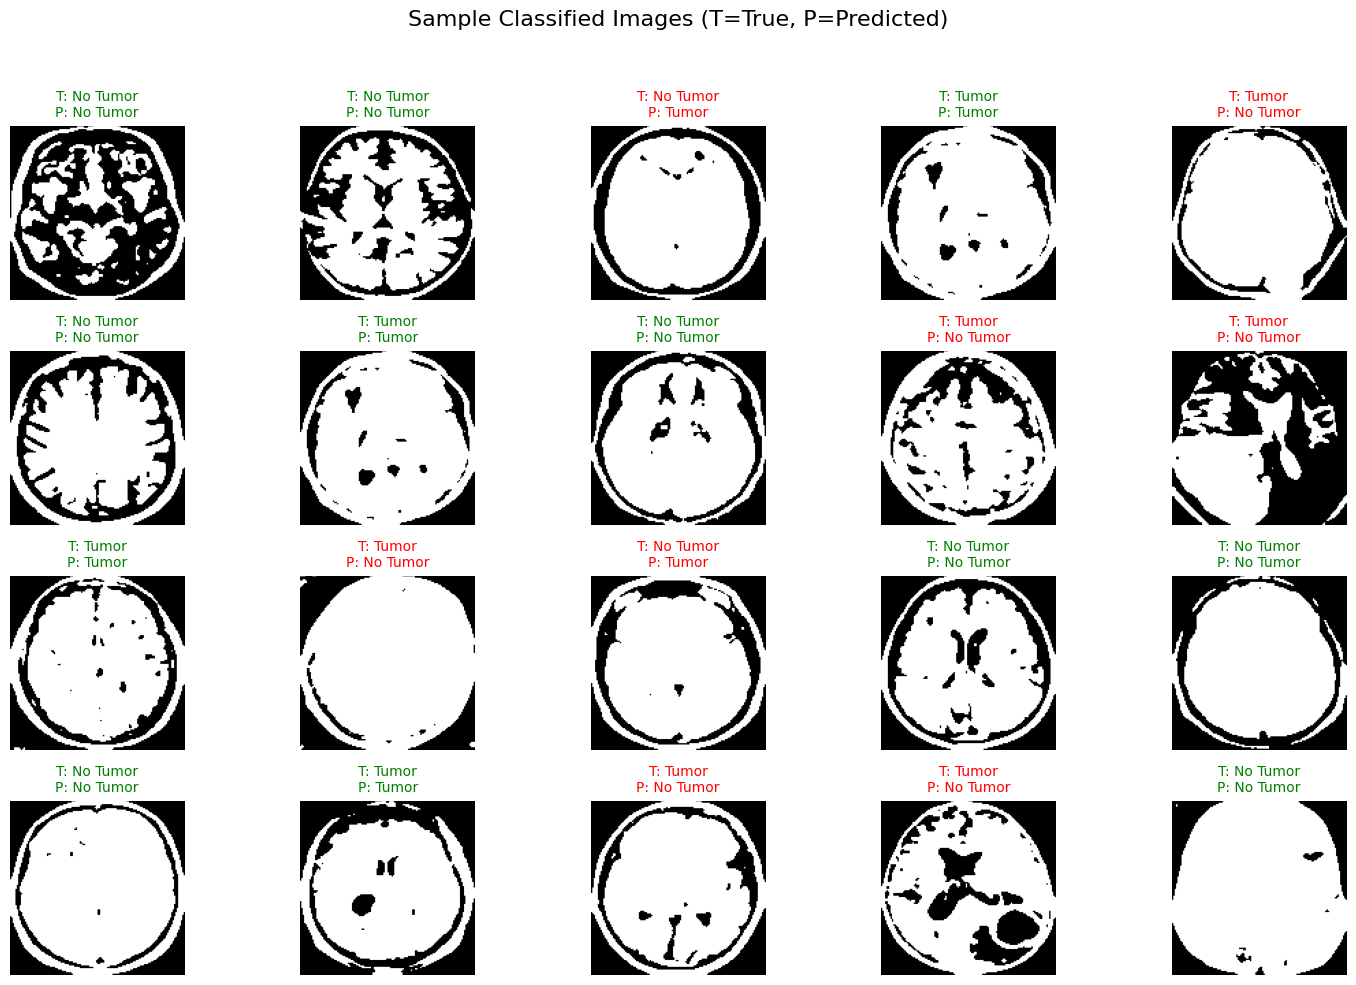


KNN - Classified Image Samples:


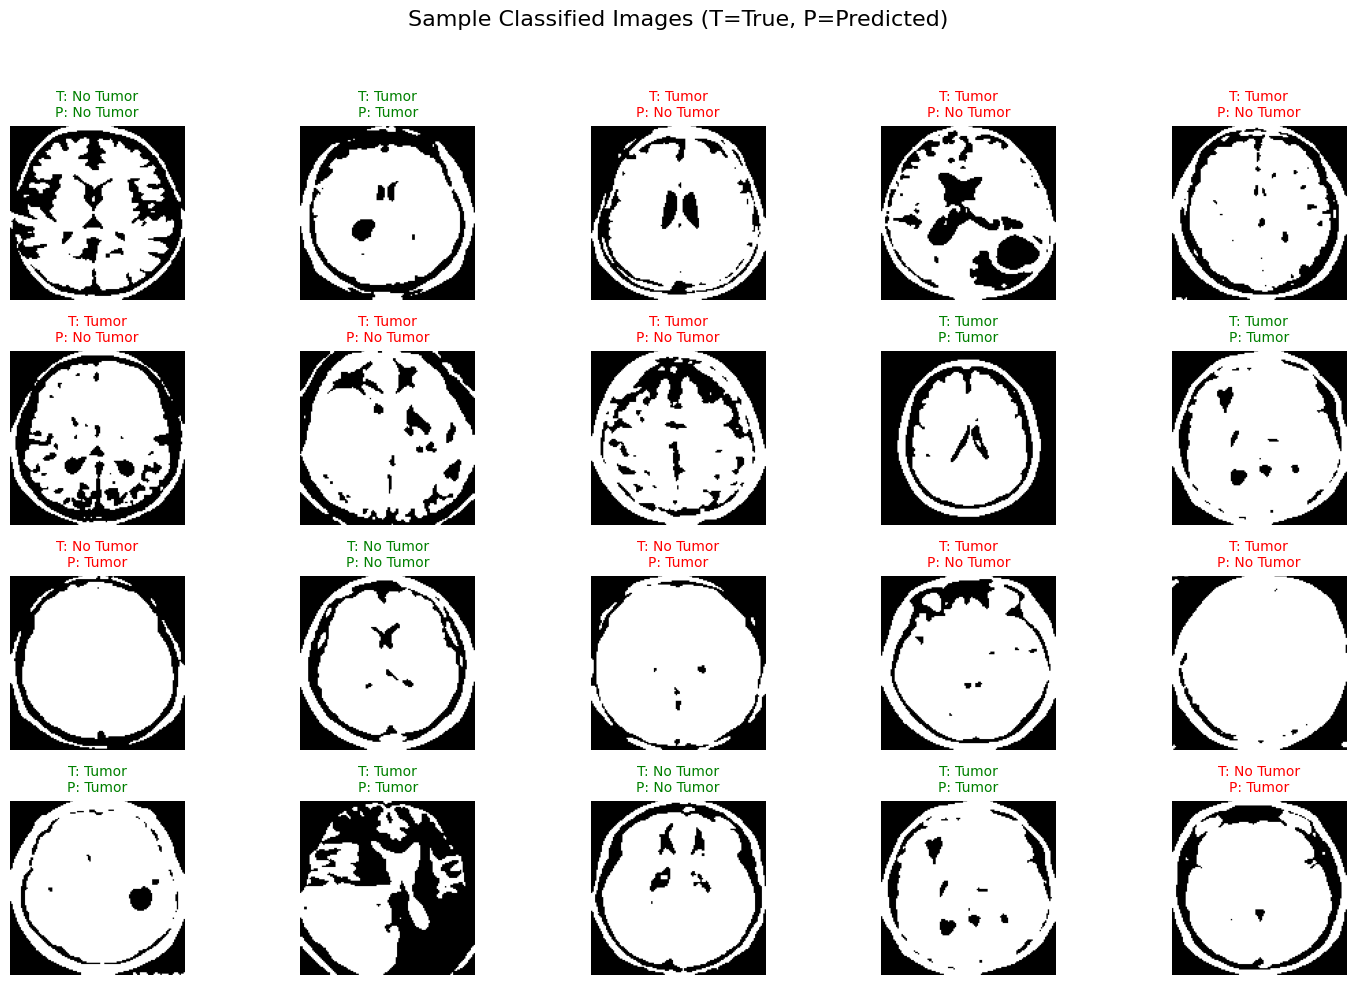

In [53]:
def display_classified_images(X_data, y_true, y_pred, original_images, label_map, num_images=20):
    plt.figure(figsize=(15, 10))
    indices = np.random.choice(len(X_data), num_images, replace=False)

    for i, idx in enumerate(indices):
        plt.subplot(4, 5, i + 1)
        plt.imshow(original_images[idx], cmap='gray')
        true_label = label_map[y_true[idx]]
        pred_label = label_map[y_pred[idx]]
        color = 'green' if y_true[idx] == y_pred[idx] else 'red'
        plt.title(f"T: {true_label}\nP: {pred_label}", color=color, fontsize=10)
        plt.axis('off')

    plt.suptitle("Sample Classified Images (T=True, P=Predicted)", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# Reverse-split features for visualization
_, X_test_raw, _, y_test_raw = train_test_split(
    features, labels, test_size=0.2, random_state=42, stratify=labels
)

# Label mapping
label_map = {0: "No Tumor", 1: "Tumor"}

# Show images for each model
for name, result in model_results.items():
    print(f"\n{name} - Classified Image Samples:")
    display_classified_images(X_test_scaled, y_test, result['y_pred'], X_test_raw, label_map)
